# 8.1D Mini Project: Sydney Housing Price Prediction and Decision Support System

## Setup

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

In [2]:
import os
os.chdir(r"D:\Notebooks\8.1D")

## Part 1: Data Loading and Cleaning

In [3]:
df = pd.read_csv("sydney_housing.csv", parse_dates=["sold_date"])
df["property_type"] = df["property_type"].replace({"apartment": "unit"})
df["is_strata"] = df["property_type"].isin(["unit", "townhouse"]).astype(int)
df["group"] = np.where(df["is_strata"] == 1, "Strata", "House")
order = ["Cabramatta", "Bankstown", "Marrickville"]

print(df.shape)
print(df.isna().sum())

(93, 13)
property_id          0
suburb               0
address              0
sold_date            0
sold_price           0
property_type        0
bedrooms             0
bathrooms            0
car_spaces           9
land_size_m2        61
building_size_m2    70
is_strata            0
group                0
dtype: int64


## Part 2: Data Understanding and Feature Engineering

#### 2.1 Price distribution

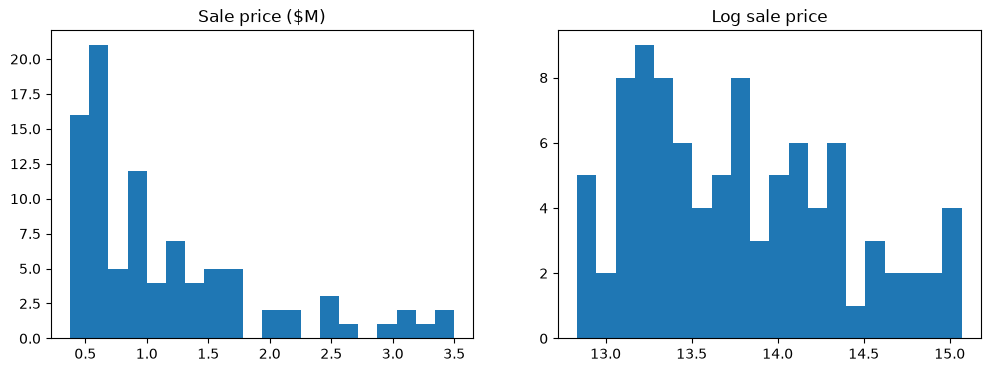

count    9.300000e+01
mean     1.155816e+06
std      7.742156e+05
min      3.750000e+05
25%      5.850000e+05
50%      9.125000e+05
75%      1.475000e+06
max      3.500000e+06
Name: sold_price, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["sold_price"] / 1e6, bins=20); ax[0].set_title("Sale price ($M)")
ax[1].hist(np.log(df["sold_price"]), bins=20); ax[1].set_title("Log sale price")
plt.show()

print(df["sold_price"].describe())

**Price distribution**

Sale prices range from 375,000 to 3.5M, with a median of 912,500 and a mean of 1.16M. The distribution is strongly right-skewed, because most sales are units under 1M while a few large houses sell above 2.5M. Taking the log of price gives a much more balanced shape, so the models are trained on log(price).

#### 2.2 Differences between suburbs

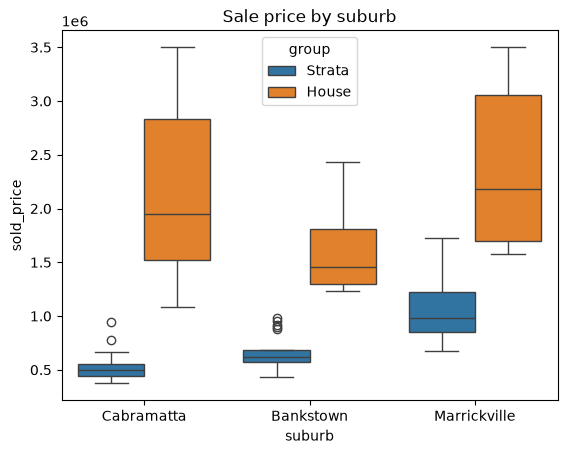

count     median
suburb       group                   
Bankstown    House       8  1459444.0
             Strata     23   620000.0
Cabramatta   House      11  1950000.0
             Strata     20   502500.0
Marrickville House       9  2185000.0
             Strata     22   982500.0

In [5]:
sns.boxplot(data=df, x="suburb", y="sold_price", hue="group", order=order)
plt.title("Sale price by suburb")
plt.show()

df.groupby(["suburb", "group"])["sold_price"].agg(["count", "median"])

**Differences between suburbs**

Property type separates prices more than suburb does. In every suburb, houses sell for roughly two to four times the price of strata properties. Among strata properties, the expected order holds: Cabramatta has the lowest median (502,500), then Bankstown (620,000), then Marrickville (982,500). The house medians do not follow this order. Cabramatta houses (1.95M) sold for more than Bankstown houses (1.46M), because the Cabramatta sample includes several new builds and very large blocks (up to 1,225 m²). This shows the sample does not fully represent each market.

#### 2.3 Trends over time

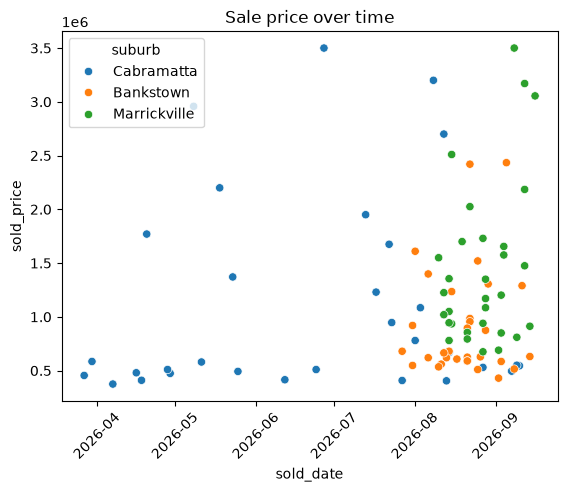

In [6]:
sns.scatterplot(data=df, x="sold_date", y="sold_price", hue="suburb")
plt.title("Sale price over time")
plt.xticks(rotation=45)
plt.show()

**Trend over time**

No clear price trend appears. Only Cabramatta covers April to September, while Bankstown and Marrickville sales fall mostly in August and September, so any time effect cannot be separated from the suburb effect.

#### 2.4 Outliers

In [7]:
q1 = df.groupby(["suburb", "group"])["sold_price"].transform(lambda s: s.quantile(0.25))
q3 = df.groupby(["suburb", "group"])["sold_price"].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
outliers = df[(df["sold_price"] < q1 - 1.5 * iqr) | (df["sold_price"] > q3 + 1.5 * iqr)]
outliers[["address", "suburb", "property_type", "bedrooms", "land_size_m2", "sold_price"]]

,address,suburb,property_type,bedrooms,land_size_m2,sold_price
7,12/39 Hill Street,Cabramatta,townhouse,3,NaN,780000
9,5/44 McBurney Road,Cabramatta,townhouse,3,NaN,947000
38,8/128 Meredith Street,Bankstown,townhouse,3,NaN,875000
43,3/53 Pringle Avenue,Bankstown,townhouse,3,231.0,985000
44,8/1 Stansfield Avenue,Bankstown,townhouse,3,231.0,955000
45,423/19-21 Meredith Street,Bankstown,unit,3,NaN,895000
59,1/192 Canterbury Road,Bankstown,townhouse,3,NaN,920000


**Outliers**

Using the IQR rule within each suburb and property group, seven properties were flagged. All are three-bedroom townhouses or units (780,000 to 985,000) that sit above the typical one- and two-bedroom units in the strata group. They are genuine sales, not errors, so they were kept. The model handles them through the bedrooms feature.

**Expected key variables**

Before feature engineering, I expected these three variables to matter most:

**Property type (house vs strata):** A house includes land, which is the main source of value in Sydney.  
**Suburb:** It captures location, distance to the CBD and transport access.  
**Bedrooms:** More bedrooms usually means a larger home that suits families, and it is the main size measure available for every property, including units where land size is missing or not comparable.

#### 2.5 Feature engineering

In [8]:
# Car spaces: blank in Marrickville = no parking (0); other blanks = typical value (1)
mar = df["suburb"] == "Marrickville"
df.loc[mar, "car_spaces"] = df.loc[mar, "car_spaces"].fillna(0)
df["car_spaces"] = df["car_spaces"].fillna(1)

# Land only counts for houses; strata = 0; missing house land = median house land
house_land = df.loc[df["is_strata"] == 0, "land_size_m2"].median()
df["land"] = np.where(df["is_strata"] == 1, 0, df["land_size_m2"].fillna(house_land))

X = pd.get_dummies(df[["bedrooms", "bathrooms", "car_spaces", "land", "is_strata", "suburb"]],
                   columns=["suburb"], drop_first=True, dtype=int)
y = np.log(df["sold_price"])   # log price because prices are right-skewed

X.assign(log_price=y).corr()["log_price"].drop("log_price").sort_values(ascending=False).round(2)

land                   0.73
bedrooms               0.73
bathrooms              0.61
car_spaces             0.47
suburb_Marrickville    0.36
suburb_Cabramatta     -0.17
is_strata             -0.79
Name: log_price, dtype: float64

## Part 3: Model Development and Evaluation

#### 3.1 Three models with 5-fold cross-validation

In [9]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42),
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
price = df["sold_price"]

results = []
for name, m in models.items():
    cv_pred = np.exp(cross_val_predict(m, X, y, cv=cv))   # predictions on unseen folds
    train_pred = np.exp(m.fit(X, y).predict(X))            # predictions on training data
    df["pred_" + name] = cv_pred
    results.append([name,
                    mean_absolute_error(price, train_pred), mean_absolute_error(price, cv_pred),
                    np.sqrt(mean_squared_error(price, cv_pred)),
                    r2_score(price, train_pred), r2_score(price, cv_pred)])

res = pd.DataFrame(results, columns=["Model", "Train MAE", "CV MAE", "CV RMSE", "Train R2", "CV R2"])
res.round({"Train MAE": 0, "CV MAE": 0, "CV RMSE": 0, "Train R2": 3, "CV R2": 3})

,Model,Train MAE,CV MAE,CV RMSE,Train R2,CV R2
0,Linear Regression,182957.0,202340.0,345708.0,0.848,0.798
1,Random Forest,132079.0,235258.0,378885.0,0.923,0.758
2,Gradient Boosting,103863.0,218574.0,369525.0,0.956,0.770


#### 3.2 Model complexity

In [10]:
rows = []
for d in [1, 2, 3, 5, 8, None]:
    m = RandomForestRegressor(n_estimators=200, max_depth=d, random_state=42)
    cv_pred = np.exp(cross_val_predict(m, X, y, cv=cv))
    train_pred = np.exp(m.fit(X, y).predict(X))
    rows.append([d, mean_absolute_error(price, train_pred), mean_absolute_error(price, cv_pred)])

pd.DataFrame(rows, columns=["max_depth", "Train MAE", "CV MAE"]).round(0)

,max_depth,Train MAE,CV MAE
0,1.0,349997.0,352851.0
1,2.0,253472.0,291044.0
2,3.0,183555.0,260963.0
3,5.0,109247.0,225394.0
4,8.0,103048.0,225279.0
5,NaN,103117.0,225518.0


## Part 4: Investigating Prediction Failures

In [11]:
best = res.loc[res["CV MAE"].idxmin(), "Model"]
print("Best model:", best)

df["pred"] = df["pred_" + best].round(0)
df["error"] = df["pred"] - df["sold_price"]
df["pct_error"] = (df["error"] / df["sold_price"] * 100).round(1)

cols = ["address", "suburb", "property_type", "bedrooms", "bathrooms", "car_spaces",
        "land_size_m2", "sold_price", "pred", "error", "pct_error"]
df.loc[df["error"].abs().sort_values(ascending=False).index[:5], cols]

Best model: Linear Regression


,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_m2,sold_price,pred,error,pct_error
13,81 Cumberland Street,Cabramatta,house,6,5,6.0,1212.0,3500000,5415781.0,1915781.0,54.7
27,3 Grace Avenue,Cabramatta,house,5,4,1.0,NaN,3200000,2197123.0,-1002877.0,-31.3
42,60 Fenwick Street,Bankstown,house,3,1,1.0,885.0,2420000,1422030.0,-997970.0,-41.2
64,11 Albermarle Street,Marrickville,house,3,1,1.0,518.5,3170000,2227149.0,-942851.0,-29.7
65,22 Fletcher Street,Marrickville,house,4,2,1.0,NaN,2185000,2911507.0,726507.0,33.2


## Part 5: Deployment
Saves the best model to `model.joblib` for the Streamlit app (`app.py`).

In [12]:
import joblib
joblib.dump({"model": models[best].fit(X, y), "columns": list(X.columns), "house_land": house_land},
            "model.joblib")
print("Saved model.joblib using", best)

Saved model.joblib using Linear Regression
